In [1]:
import requests
import pandas as pd
import numpy as np
from binance.client import Client
import datetime

from itertools import combinations
import statsmodels.api as sm


## Load Data and filter the top 20 by market cap

In [2]:
url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 50,   # pull more so filtering still leaves ~20
    "page": 1,
    "sparkline": False
    
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data)[
    ["market_cap_rank", "symbol", "name", "market_cap", "current_price"]
]

# -----------------------------
# Filters
# -----------------------------

stablecoins = {
    "usdt", "usdc", "busd", "dai", "tusd",
    "usdp", "fdusd", "gusd", "lusd",
    "ust", "ustc", "usdd", "eurc",'usds','usde','bsc-usd','usd1','pyusd'
    
}

# normalize text
df["symbol"] = df["symbol"].str.lower()
df["name"] = df["name"].str.lower()

# remove stablecoins
df = df[~df["symbol"].isin(stablecoins)]

# remove wrapped coins
df = df[
    ~df["name"].str.contains("wrapped") &
    ~df["symbol"].str.startswith("w")
]

# take top 20 after filtering
df = df.sort_values("market_cap", ascending=False).head(20)

print(df)


    market_cap_rank      symbol          name     market_cap  current_price
0                 1         btc       bitcoin  1392088727028   69595.000000
1                 2         eth      ethereum   245226709296    2031.630000
3                 4         bnb           bnb    87028067178     638.220000
4                 5         xrp           xrp    84457290219       1.380000
6                 7         sol        solana    48663310492      85.210000
7                 8         trx          tron    27292577123       0.288059
8                 9  figr_heloc  figure heloc    16292022193       1.036000
9                10        doge      dogecoin    14150955294       0.092269
12               13         ada       cardano     9567713313       0.259763
13               14         bch  bitcoin cash     8989806023     449.360000
14               15         leo     leo token     8451986246       9.180000
15               16        hype   hyperliquid     8246561791      34.770000
16          

## Get symbol from Binance, using binance data and later using binance api for trading test.


In [3]:
binance_symbols = requests.get(
    "https://api.binance.com/api/v3/exchangeInfo"
).json()

binance_assets = {
    s["baseAsset"].lower()
    for s in binance_symbols["symbols"]
    if s["quoteAsset"] == "USDT"
}

df = df[df["symbol"].isin(binance_assets)]

In [4]:
client = Client()


def get_close_prices_15m(
    client,
    symbols,
    start_date,
    end_date
):

    close_dfs = []

    for sym in symbols:
        pair = sym.upper() + "USDT"
        print(f"Downloading {pair}")

        klines = client.get_historical_klines(
            pair,
            Client.KLINE_INTERVAL_15MINUTE,
            start_date.strftime("%d %b %Y %H:%M:%S"),
            end_date.strftime("%d %b %Y %H:%M:%S")
        )

        df = pd.DataFrame(klines, columns=[
            "timestamp", "open", "high", "low", "close", "volume",
            "close_time", "quote_asset_volume", "number_of_trades",
            "taker_buy_base", "taker_buy_quote", "ignore"
        ])

        df = df[["timestamp", "close"]]
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
        df["close"] = df["close"].astype(float)

        df = df.rename(columns={"close": sym.upper()})

        close_dfs.append(df)

    # ---- merge all coins on timestamp ----
    df_close = close_dfs[0]

    for d in close_dfs[1:]:
        df_close = df_close.merge(
            d,
            on="timestamp",
            how="outer"
        )

    df_close = (
        df_close
        .sort_values("timestamp")
        .set_index("timestamp")
    )

    return df_close


In [5]:
#start_date = datetime(2025, 1, 1)
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=30)


df_close_15m = get_close_prices_15m(
    client,
    df['symbol'].tolist(),
    start_date,
    end_date
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_21276\2955754956.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_21276\2955754956.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_21276\2955754956.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_21276\2955754956.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_21276\2955754956.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


...

C:\Users\Acer\AppData\Local\Temp\ipykernel_21276\2955754956.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(
C:\Users\Acer\AppData\Local\Temp\ipykernel_21276\2955754956.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_21276\2955754956.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_21276\2955754956.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_21276\2955754956.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_21276\2955754956.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


### visualise price change over time

In [6]:
import numpy as np

base = df_close_15m.iloc[0]
bad_cols = base[(base.isna()) | (base == 0)].index
print("Bad columns:", bad_cols)
df_close_15m = df_close_15m.drop(columns=bad_cols)

Bad columns: Index(['XMR'], dtype='object')


Text(0, 0.5, 'Price')

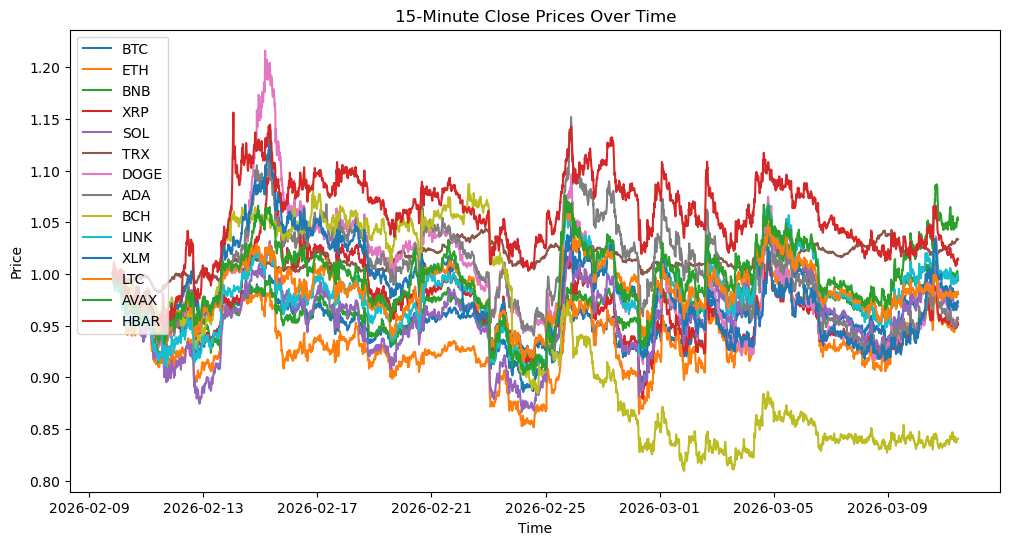

In [7]:
import matplotlib.pyplot as plt

normalized_df = df_close_15m / df_close_15m.iloc[0]  # Normalize to the first row

plt.figure(figsize=(12, 6))
for col in normalized_df.columns:
    plt.plot(normalized_df.index, normalized_df[col], label=col)
plt.legend()
plt.title("15-Minute Close Prices Over Time")
plt.xlabel("Time")
plt.ylabel("Price")

In [8]:
df_close=df_close_15m.copy()

In [9]:
df_close_15m.dropna(inplace=True, axis=0)

In [10]:
df_close_15m

,BTC,ETH,BNB,XRP,SOL,TRX,DOGE,ADA,BCH,LINK,XLM,LTC,AVAX,HBAR
timestamp,,,,,,,,,,,,,,
2026-02-09 19:30:00,70928.68,2130.59,642.17,1.4497,87.96,0.2789,0.09638,0.2713,534.7,8.97,0.1614,54.95,9.11,0.09267
2026-02-09 19:45:00,70957.01,2131.34,642.48,1.4528,87.97,0.2789,0.09636,0.2711,535.1,8.97,0.1615,54.98,9.11,0.09282
2026-02-09 20:00:00,70987.99,2140.68,642.41,1.4511,88.01,0.2791,0.09640,0.2715,537.4,8.97,0.1614,55.04,9.12,0.09282
2026-02-09 20:15:00,70550.15,2119.81,638.97,1.4463,87.32,0.2789,0.09593,0.2696,534.1,8.89,0.1605,54.82,9.06,0.09258
2026-02-09 20:30:00,70832.00,2129.37,640.98,1.4527,87.71,0.2788,0.09646,0.2710,534.4,8.91,0.1615,54.97,9.09,0.09350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-11 10:15:00,69500.00,2021.05,641.73,1.3768,85.14,0.2883,0.09185,0.2585,448.9,8.93,0.1563,53.89,9.56,0.09355
2026-03-11 10:30:00,69683.21,2029.27,644.00,1.3803,85.49,0.2884,0.09221,0.2597,449.2,8.96,0.1569,53.98,9.59,0.09393
2026-03-11 10:45:00,69604.90,2028.68,643.79,1.3787,85.25,0.2882,0.09225,0.2594,449.2,8.95,0.1568,53.92,9.58,0.09386


## Run Cointegration Test
### select BTC related pairs

In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from itertools import combinations

def test_cointegration_kalman(series_x, series_y, delta=1e-4):
    """
    Stationarity test using a Kalman Filter for dynamic hedge ratios
    """
    # 1️⃣ Kalman Filter to calculate rolling Alpha and Beta
    state_mean = np.zeros(2)
    state_cov = np.ones((2, 2))
    
    Q = (delta / (1 - delta)) * np.eye(2) 
    R = 1.0 
    
    rolling_alpha = []
    rolling_beta = []
    
    # Iterate through the time series
    for i in range(len(series_x)):
        x_t = series_x.iloc[i]
        y_t = series_y.iloc[i]
        
        H = np.array([[1.0, x_t]])
        
        # Prediction Step
        state_mean_pred = state_mean
        state_cov_pred = state_cov + Q
        
        # Update Step
        y_pred = H.dot(state_mean_pred)
        error = y_t - y_pred
        
        S = H.dot(state_cov_pred).dot(H.T) + R
        K = state_cov_pred.dot(H.T) / S
        
        state_mean = state_mean_pred + (K.flatten() * error)
        state_cov = (np.eye(2) - K.dot(H)).dot(state_cov_pred)
        
        rolling_alpha.append(state_mean[0])
        rolling_beta.append(state_mean[1])
        
    rolling_alpha = pd.Series(rolling_alpha, index=series_x.index)
    rolling_beta = pd.Series(rolling_beta, index=series_x.index)

    # 2️⃣ Calculate Dynamic Spread
    spread = series_y - (rolling_beta * series_x + rolling_alpha)

    # 3️⃣ Stationarity test (ADF) directly on the dynamic spread
    # We drop NA values that might occur during the initial filter convergence
    adf_result = adfuller(spread.dropna())
    
    t_stat = adf_result[0]
    pvalue = adf_result[1]
    crit_values = adf_result[4]

    return {
        "latest_beta": rolling_beta.iloc[-1], # Return the most recent beta for the summary table
        "pvalue": pvalue,
        "t_stat": t_stat,
        "crit_1%": crit_values['1%'],
        "crit_5%": crit_values['5%'],
        "crit_10%": crit_values['10%'],
        "spread": spread,
        "rolling_beta_series": rolling_beta # Stored in case you need to plot it later
    }

# --- Execution Loop ---
results = []
pairs = list(combinations(normalized_df.columns, 2))

for x, y in pairs:
    res = test_cointegration_kalman(normalized_df[x], normalized_df[y])

    results.append({
        "pair": f"{x}-{y}",
        "x": x,
        "y": y,
        "latest_beta": res["latest_beta"],
        "pvalue": res["pvalue"],
        "t_stat": res["t_stat"],
        "crit_5%": res["crit_5%"]
    })

# Format and filter the results
df_coint = pd.DataFrame(results)
coint_pairs = df_coint[df_coint["pvalue"] < 0.05]
coint_pairs = coint_pairs.sort_values("pvalue")

# Filter for pairs specifically involving BTC
btc_pairs = coint_pairs[
    (coint_pairs["x"] == "BTC") |
    (coint_pairs["y"] == "BTC")
]

display(btc_pairs)

,pair,x,y,latest_beta,pvalue,t_stat,crit_5%
7,BTC-BCH,BTC,BCH,0.439772,1.244819e-21,-11.745424,-2.862556
1,BTC-BNB,BTC,BNB,0.519433,1.923969e-19,-10.809583,-2.862556
10,BTC-LTC,BTC,LTC,0.515552,5.980317e-15,-9.015094,-2.862556
8,BTC-LINK,BTC,LINK,0.542693,8.140252e-12,-7.786773,-2.862556
12,BTC-HBAR,BTC,HBAR,0.534736,1.694303e-11,-7.660439,-2.862556
9,BTC-XLM,BTC,XLM,0.519976,6.735821e-11,-7.421030,-2.862556
0,BTC-ETH,BTC,ETH,0.518313,1.625161e-08,-6.439066,-2.862556
2,BTC-XRP,BTC,XRP,0.506148,1.812925e-08,-6.418816,-2.862556
4,BTC-TRX,BTC,TRX,0.495134,1.974537e-08,-6.402978,-2.862557
11,BTC-AVAX,BTC,AVAX,0.561574,2.339956e-07,-5.934357,-2.862556


Analyzing the most cointegrated pair: BTC & BCH


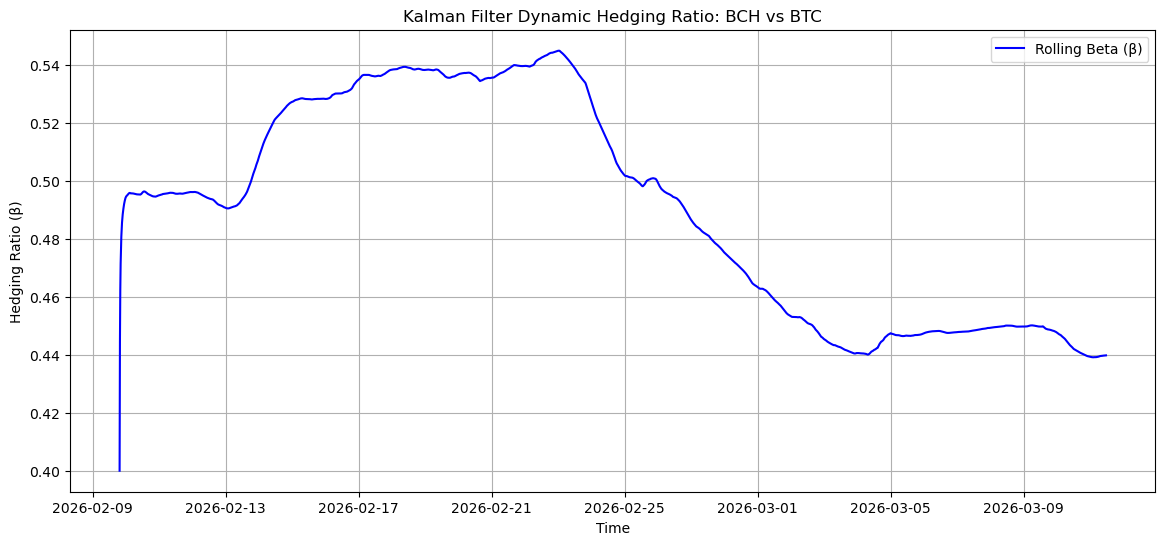

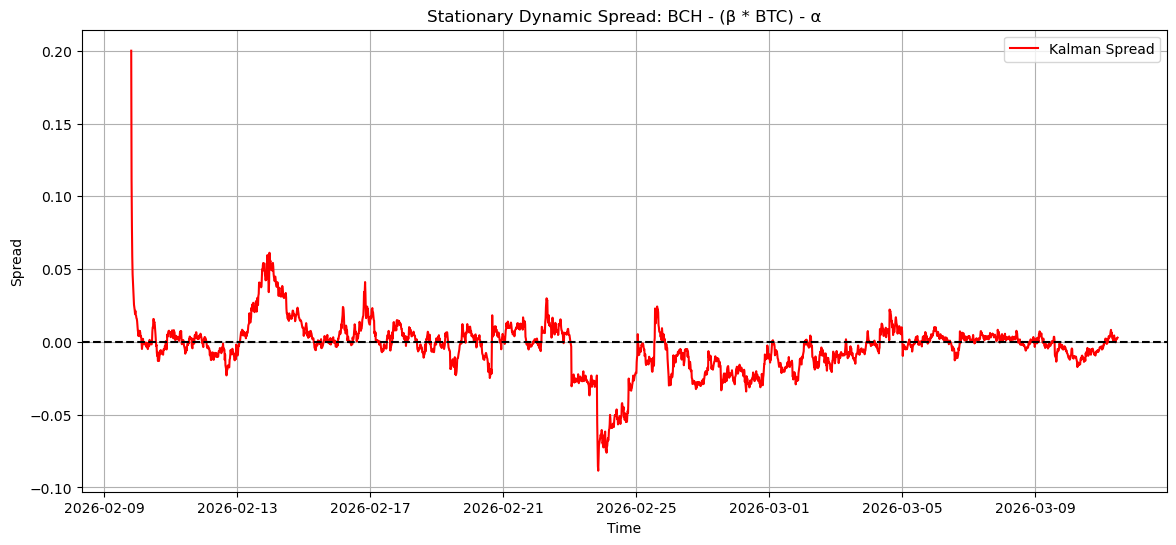

In [12]:
import matplotlib.pyplot as plt

# 1. Select the most cointegrated BTC pair (the one with the lowest p-value)
best_x = btc_pairs.iloc[0]['x']
best_y = btc_pairs.iloc[0]['y']
print(f"Analyzing the most cointegrated pair: {best_x} & {best_y}")

# 2. Re-run the Kalman Filter specifically for this pair to get the full time series
kalman_results = test_cointegration_kalman(normalized_df[best_x], normalized_df[best_y])

rolling_beta = kalman_results["rolling_beta_series"]
dynamic_spread = kalman_results["spread"]

# 3. Plot the Dynamic Hedging Ratio (Beta)
plt.figure(figsize=(14, 6))
plt.plot(rolling_beta.index, rolling_beta, label=f'Rolling Beta (\u03b2)', color='blue')
plt.title(f'Kalman Filter Dynamic Hedging Ratio: {best_y} vs {best_x}')
plt.xlabel('Time')
plt.ylabel('Hedging Ratio (\u03b2)')
plt.legend()
plt.grid(True)
plt.show()

# 4. Plot the resulting Dynamic Spread for visualization
plt.figure(figsize=(14, 6))
plt.plot(dynamic_spread.index, dynamic_spread, label='Kalman Spread', color='red')
plt.axhline(0, color='black', linestyle='--', lw=1.5)
plt.title(f'Stationary Dynamic Spread: {best_y} - (\u03b2 * {best_x}) - \u03b1')
plt.xlabel('Time')
plt.ylabel('Spread')
plt.legend()
plt.grid(True)
plt.show()

## Modelling

In [13]:
def build_spread(prices: pd.DataFrame, x: str, y: str, beta: float, use_log=True):
    px = prices[x].astype(float)
    py = prices[y].astype(float)
    if use_log:
        px = np.log(px)
        py = np.log(py)
    spread = py - beta * px
    return spread.dropna()

In [14]:
def run_ou_for_pairs(pairs_df, prices, window=1000, delta=1.0):
    """
    Fits the rolling OU process on the dynamic Kalman spread 
    and generates Z-score signals.
    """
    ou_results = []
    
    for idx, row in pairs_df.iterrows():
        x = row['x']
        y = row['y']
        print(f"Generating signals for {x}-{y}...")
        
        # 1. Re-run Kalman filter to get the exact rolling spread and beta
        kalman_res = test_cointegration_kalman(prices[x], prices[y])
        dynamic_spread = kalman_res['spread']
        rolling_beta = kalman_res['rolling_beta_series']
        
        # 2. Get rolling OU parameters (using the function we defined earlier)
        df_ou = get_rolling_ou_params(dynamic_spread, window=window, delta=delta)
        
        # 3. Generate Trading Signal (Standardized Z-score)
        # Z = (Spread - rolling_mu) / rolling_sigma
        z_score = (dynamic_spread - df_ou['ou_mean']) / df_ou['ou_sigma']
        
        ou_results.append({
            "pair": f"{x}-{y}",
            "x": x,
            "y": y,
            "beta_series": rolling_beta, # We store the entire Series, not a static number!
            "signal": z_score,
            "spread": dynamic_spread
        })
        
    return ou_results

# Execute it
ou_results = run_ou_for_pairs(btc_pairs, df_close_15m, window=1000)

Generating signals for BTC-BCH...


NameError: name 'get_rolling_ou_params' is not defined

In [ ]:
def ou_zscore(spread: pd.Series, mu: float, sigma: float):
    return (spread - mu) / sigma

def percentile_signals(z: pd.Series, lookback=24*4, p_low=25, p_high=75, p_exit=50):
    sig = pd.Series(0, index=z.index, dtype=int)

    for i in range(lookback, len(z)):
        hist = z.iloc[i-lookback:i]
        lo = np.percentile(hist, p_low)
        hi = np.percentile(hist, p_high)
        mid = np.percentile(hist, p_exit)

        if z.iloc[i] > hi:
            sig.iloc[i] = -1   # short spread
        elif z.iloc[i] < lo:
            sig.iloc[i] = 1    # long spread
        elif (z.iloc[i-1] - mid) * (z.iloc[i] - mid) <= 0:
            sig.iloc[i] = 0    # exit when cross mid
        else:
            sig.iloc[i] = sig.iloc[i-1]  # hold previous position

    return sig

In [ ]:
def walk_forward_signals(prices, x, y, train_window, trade_window):

    signals = []
    z_scores = []

    for start in range(train_window, len(prices) - trade_window, trade_window):

        train = prices.iloc[start-train_window:start]
        test  = prices.iloc[start:start+trade_window]
        # test if cointegration holds
        score, pvalue, _ = coint(train[x], train[y])

        #if pvalue > 0.2:
            #print(f"Window starting at {train.index[0]}: pair {x}-{y} not cointegrated (p={pvalue:.4f}) → skipping")
            # pair not cointegrated → skip trading this window
            #continue

        # --------
        # 1 estimate beta
        # --------
        X = sm.add_constant(train[x])
        model = sm.OLS(train[y], X).fit()
        beta = model.params[x]

        # --------
        # 2 build spread
        # --------
        spread_train = train[y] - beta * train[x]

        # --------
        # 3 fit OU
        # --------
        ou = fit_ou_from_spread(spread_train)

        # --------
        # 4 compute zscore on test window
        # --------
        spread_test = test[y] - beta * test[x]
        z = ou_zscore(spread_test, ou["mu"], ou["sigma"])

        # --------
        # 5 generate signals
        # --------
        sig = percentile_signals(z, lookback=720)

        signals.append(sig)
        z_scores.append(z)

    signals = pd.concat(signals)
    z_scores = pd.concat(z_scores)
    return z_scores, signals

In [ ]:
def run_ou_for_pairs(pairs_df: pd.DataFrame, prices: pd.DataFrame, delta=1.0):
    results = []

    for _, row in pairs_df.iterrows():
        x, y, beta = row["x"], row["y"], float(row["beta"])

        z, sig = walk_forward_signals(prices=df_close_15m, x=x, y=y,train_window=24*4*25,trade_window=24*4) # 20 days train, 1 day test

        results.append({
            "pair": f"{x}-{y}",
            "beta": beta,
            'z_scores' : z,
            "signal": sig
        })

    return results

In [ ]:
ou_results = run_ou_for_pairs(btc_pairs, df_close_15m)

KeyError: 'beta'

In [ ]:
ou_results

[{'pair': 'BTC-ETH',
  'beta': 1.1123576512419024,
  'z_scores': timestamp
  2026-02-28 17:00:00     1.202616
  2026-02-28 17:15:00     0.906057
  2026-02-28 17:30:00    -0.767067
  2026-02-28 17:45:00    -0.804762
  2026-02-28 18:00:00    -0.295812
                           ...    
  2026-03-04 15:45:00   -11.634162
  2026-03-04 16:00:00   -10.234685
  2026-03-04 16:15:00    -9.091667
  2026-03-04 16:30:00   -10.234809
  2026-03-04 16:45:00   -12.834578
  Length: 384, dtype: float64,
  'signal': timestamp
  2026-02-28 17:00:00    0
  2026-02-28 17:15:00    0
  2026-02-28 17:30:00    0
  2026-02-28 17:45:00    0
  2026-02-28 18:00:00    0
                        ..
  2026-03-04 15:45:00    0
  2026-03-04 16:00:00    0
  2026-03-04 16:15:00    0
  2026-03-04 16:30:00    0
  2026-03-04 16:45:00    0
  Length: 384, dtype: int64},
 {'pair': 'BTC-SOL',
  'beta': 1.184315648327566,
  'z_scores': timestamp
  2026-02-28 17:00:00    7.887492
  2026-02-28 17:15:00    7.316386
  2026-02-28 17:30

In [ ]:

ou_df = pd.DataFrame([
    {
        "pair": r["pair"],
        "beta": r["beta"],
        "z_scores": r["z_scores"]
        
    }
    for r in ou_results
])




,pair,beta,z_scores
0,BTC-ETH,1.112358,timestamp 2026-02-28 17:00:00 1.202616 202...
1,BTC-SOL,1.184316,timestamp 2026-02-28 17:00:00 7.887492 2026...


In [ ]:
signals_df = pd.concat(
    {r["pair"]: r["signal"] for r in ou_results},
    axis=1
).sort_index()

In [ ]:
signals_df

,BTC-ETH,BTC-SOL
timestamp,,
2026-02-28 17:00:00,0,0
2026-02-28 17:15:00,0,0
2026-02-28 17:30:00,0,0
2026-02-28 17:45:00,0,0
2026-02-28 18:00:00,0,0
...,...,...
2026-03-04 15:45:00,0,0
2026-03-04 16:00:00,0,0
2026-03-04 16:15:00,0,0


In [ ]:


# -----------------------------
# Helpers: performance metrics
# -----------------------------
def _max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())

def _sharpe(returns: pd.Series, bars_per_year: int) -> float:
    r = returns.dropna()
    if len(r) < 2:
        return np.nan
    mu = r.mean()
    sd = r.std(ddof=1)
    if sd == 0:
        return np.nan
    return float((mu / sd) * np.sqrt(bars_per_year))

def _trade_stats(signal: pd.Series, pnl: pd.Series):
    """
    Approx trade stats using "position episodes" (when signal != 0).
    """
    s = signal.fillna(0).astype(int)
    pnl = pnl.fillna(0.0)

    # Episode start: 0 -> +/-1 ; Episode end: +/-1 -> 0 or sign flip
    changes = s.diff().fillna(s.iloc[0]).astype(int)

    # indices where a new position is entered
    entry_idx = s[(s != 0) & (changes != 0)].index
    # indices where position is exited (or flipped)
    exit_idx = s[(s == 0) & (changes != 0)].index

    # If last trade is still open, ignore it for winrate stats
    # Build episodes by walking entries and matching next exit
    episodes = []
    for ei in entry_idx:
        # find first exit after entry
        exits_after = exit_idx[exit_idx > ei]
        if len(exits_after) == 0:
            break
        xo = exits_after[0]
        ep_pnl = pnl.loc[ei:xo].sum()
        episodes.append(ep_pnl)

    if len(episodes) == 0:
        return {
            "num_trades": 0,
            "win_rate": np.nan,
            "avg_trade_pnl": np.nan,
            "median_trade_pnl": np.nan,
            "profit_factor": np.nan,
        }

    ep = np.array(episodes, dtype=float)
    wins = ep[ep > 0]
    losses = ep[ep < 0]

    profit_factor = np.nan
    if losses.size > 0:
        profit_factor = wins.sum() / (-losses.sum()) if wins.size > 0 else 0.0

    return {
        "num_trades": int(len(ep)),
        "win_rate": float((ep > 0).mean()),
        "avg_trade_pnl": float(ep.mean()),
        "median_trade_pnl": float(np.median(ep)),
        "profit_factor": float(profit_factor) if not np.isnan(profit_factor) else np.nan,
    }



In [ ]:

# -----------------------------
# Core: perp pair backtester
# -----------------------------
def backtest_pair_perps(
    prices: pd.DataFrame,
    x: str,
    y: str,
    beta: float,
    signal: pd.Series,
    *,
    initial_capital: float = 10_000.0,
    leverage: float = 3.0,
    alloc: float = 1.0,                 # fraction of equity used for gross notional (before leverage)
    fee_rate: float = 0.0004,           # e.g. 4 bps taker; adjust for your assumed execution
    slippage_bps: float = 1.0,          # extra bps per notional traded (0..)
    bars_per_year: int = 365 * 24 * 4,  # 15m bars
    allow_flip_same_bar: bool = True,
) -> dict:
    """
    Signal convention (same as your notebook):
      +1 = long spread  -> LONG y, SHORT x * beta
      -1 = short spread -> SHORT y, LONG x * beta
       0 = flat

    PnL is linear perp-style:
      PnL_t = pos_units_prev * (price_t - price_{t-1}) summed across legs
    Fees/slippage are charged on traded NOTIONAL when position changes.
    """

    # Align & clean
    px = prices[x].astype(float).copy()
    py = prices[y].astype(float).copy()
    df = pd.concat([px.rename("px"), py.rename("py"), signal.rename("sig")], axis=1).dropna()
    df["sig"] = df["sig"].astype(int)

    if len(df) < 5:
        return {"pair": f"{x}-{y}", "df": df, "stats": {"error": "not enough data"}}

    # Containers
    equity = np.zeros(len(df), dtype=float)
    pnl = np.zeros(len(df), dtype=float)
    fees = np.zeros(len(df), dtype=float)

    # Position units (contracts) on each leg
    ux = np.zeros(len(df), dtype=float)
    uy = np.zeros(len(df), dtype=float)

    equity[0] = initial_capital

    prev_sig = 0
    prev_ux = 0.0
    prev_uy = 0.0

    # We use absolute beta weight for notional split
    w_x = abs(beta)
    w_y = 1.0
    denom = (w_x + w_y) if (w_x + w_y) != 0 else 1.0

    for i in range(1, len(df)):
        px_prev, py_prev = float(df["px"].iloc[i - 1]), float(df["py"].iloc[i - 1])
        px_now,  py_now  = float(df["px"].iloc[i]),     float(df["py"].iloc[i])
        sig_now = int(df["sig"].iloc[i])

        # 1) Mark-to-market from previous holdings
        mtm = prev_ux * (px_now - px_prev) + prev_uy * (py_now - py_prev)
        pnl[i] = mtm
        equity[i] = equity[i - 1] + mtm

        # 2) Decide target position (units) based on signal
        #    Notional sizing uses current equity AFTER mtm.
        #    Gross notional = equity * alloc * leverage
        gross = max(equity[i], 0.0) * float(alloc) * float(leverage)

        # Target notionals per leg (split by weights)
        ny = gross * (w_y / denom)
        nx = gross * (w_x / denom)

        # Convert to units (linear perp): units = notional / price
        if sig_now == 0:
            tgt_ux, tgt_uy = 0.0, 0.0
        elif sig_now == 1:
            # long spread: long y, short x*beta
            tgt_uy = + (ny / py_now)
            tgt_ux = - np.sign(beta) * (nx / px_now)  # beta sign determines hedge direction
        else:  # sig_now == -1
            tgt_uy = - (ny / py_now)
            tgt_ux = + np.sign(beta) * (nx / px_now)

        # 3) Trading costs if position changes
        # If you don't want flip-in-same-bar behavior, you can disallow it.
        changed = (sig_now != prev_sig)
        if changed and (not allow_flip_same_bar) and (prev_sig != 0) and (sig_now != 0):
            # force to flat first; then next bar will enter new side
            tgt_ux, tgt_uy = 0.0, 0.0
            sig_now = 0

        dx = tgt_ux - prev_ux
        dy = tgt_uy - prev_uy

        traded_notional = abs(dx) * px_now + abs(dy) * py_now
        cost = traded_notional * (fee_rate + (slippage_bps / 10_000.0))

        fees[i] = cost
        equity[i] -= cost  # deduct costs

        # 4) Set positions for next bar
        ux[i] = tgt_ux
        uy[i] = tgt_uy
        prev_ux, prev_uy = tgt_ux, tgt_uy
        prev_sig = int(df["sig"].iloc[i])

    out = df.copy()
    out["ux"] = ux
    out["uy"] = uy
    out["pnl"] = pnl
    out["fees"] = fees
    out["equity"] = equity
    out["ret"] = out["equity"].pct_change().fillna(0.0)

    # Turnover: traded notional / equity (rough)
    traded = (out["ux"].diff().abs() * out["px"] + out["uy"].diff().abs() * out["py"]).fillna(0.0)
    out["turnover"] = traded / out["equity"].replace(0, np.nan)

    stats = {
        "pair": f"{x}-{y}",
        "beta": float(beta),
        "initial_capital": float(initial_capital),
        "final_equity": float(out["equity"].iloc[-1]),
        "total_pnl": float(out["pnl"].sum() - out["fees"].sum()),
        "gross_pnl": float(out["pnl"].sum()),
        "total_fees": float(out["fees"].sum()),
        "sharpe": _sharpe(out["ret"], bars_per_year=bars_per_year),
        "max_drawdown": _max_drawdown(out["equity"]),
        "avg_turnover": float(out["turnover"].replace([np.inf, -np.inf], np.nan).dropna().mean())
                        if out["turnover"].notna().any() else np.nan,
    }
    stats.update(_trade_stats(out["sig"], out["pnl"] - out["fees"]))

    return {"pair": f"{x}-{y}", "df": out, "stats": stats}



In [ ]:
# -----------------------------
# Run it on your ou_results
# -----------------------------
all_stats = []
bt_results = {}

for r in ou_results:
    pair = r["pair"]           # e.g. "BTC-ETH"
    beta_series = r["beta_series"] # Extract the ROLLING beta
    sig = r["signal"]          # pd.Series indexed by timestamp 

    x, y = pair.split("-")
    
    res = backtest_pair_perps(
        prices=df_close_15m,
        x=x, y=y,
        beta=beta_series,      # <-- Pass the dynamic beta here for accurate position sizing
        signal=sig,
        initial_capital=10_000,
        leverage=3.0,
        alloc=1,
        fee_rate=0.0004,
        slippage_bps=1.0,
        bars_per_year=365*24*4, # 15m
    )

    bt_results[pair] = res
    all_stats.append(res["stats"])

# View results
stats_df = pd.DataFrame(all_stats).sort_values("sharpe", ascending=False)
display(stats_df)

,pair,beta,initial_capital,final_equity,total_pnl,gross_pnl,total_fees,sharpe,max_drawdown,avg_turnover,num_trades,win_rate,avg_trade_pnl,median_trade_pnl,profit_factor
0,BTC-ETH,1.112358,10000.0,10000.0,0.0,0.0,0.0,NaN,0.0,0.0,0,NaN,NaN,NaN,NaN
1,BTC-SOL,1.184316,10000.0,10000.0,0.0,0.0,0.0,NaN,0.0,0.0,0,NaN,NaN,NaN,NaN


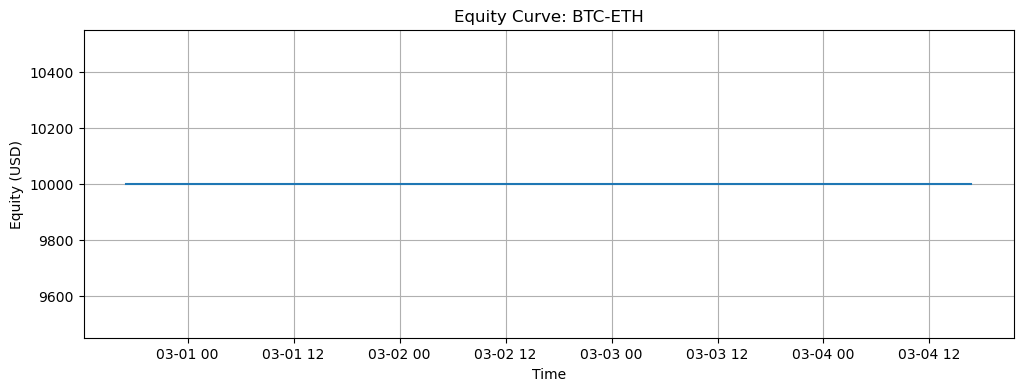

{'pair': 'BTC-ETH',
 'beta': 1.1123576512419024,
 'initial_capital': 10000.0,
 'final_equity': 10000.0,
 'total_pnl': 0.0,
 'gross_pnl': 0.0,
 'total_fees': 0.0,
 'sharpe': nan,
 'max_drawdown': 0.0,
 'avg_turnover': 0.0,
 'num_trades': 0,
 'win_rate': nan,
 'avg_trade_pnl': nan,
 'median_trade_pnl': nan,
 'profit_factor': nan}

In [ ]:
import matplotlib.pyplot as plt

best_pair = stats_df.iloc[0]["pair"]
eq = bt_results[best_pair]["df"]["equity"]

plt.figure(figsize=(12,4))
plt.plot(eq.index, eq.values)
plt.title(f"Equity Curve: {best_pair}")
plt.xlabel("Time")
plt.ylabel("Equity (USD)")
plt.grid(True)
plt.show()

bt_results[best_pair]["stats"]

In [ ]:
def build_trade_log(bt_df: pd.DataFrame):

    trades = []
    position = 0
    entry_time = None
    entry_px = None
    entry_py = None

    for i in range(1, len(bt_df)):

        sig_prev = bt_df["sig"].iloc[i-1]
        sig_now  = bt_df["sig"].iloc[i]

        px = bt_df["px"].iloc[i]
        py = bt_df["py"].iloc[i]
        time = bt_df.index[i]

        # ENTRY
        if position == 0 and sig_now != 0:
            position = sig_now
            entry_time = time
            entry_px = px
            entry_py = py

        # EXIT
        elif position != 0 and sig_now == 0:

            exit_time = time
            exit_px = px
            exit_py = py

            pnl = bt_df.loc[entry_time:exit_time, "pnl"].sum() \
                  - bt_df.loc[entry_time:exit_time, "fees"].sum()

            trades.append({
                "entry_time": entry_time,
                "exit_time": exit_time,
                "direction": "long_spread" if position == 1 else "short_spread",
                "entry_px_x": entry_px,
                "entry_px_y": entry_py,
                "exit_px_x": exit_px,
                "exit_px_y": exit_py,
                "holding_minutes": (exit_time - entry_time).total_seconds() / 60,
                "pnl": pnl
            })

            position = 0
            entry_time = None

        # FLIP POSITION
        elif position != 0 and sig_now == -position:

            exit_time = time
            exit_px = px
            exit_py = py

            pnl = bt_df.loc[entry_time:exit_time, "pnl"].sum() \
                  - bt_df.loc[entry_time:exit_time, "fees"].sum()

            trades.append({
                "entry_time": entry_time,
                "exit_time": exit_time,
                "direction": "long_spread" if position == 1 else "short_spread",
                "entry_px_x": entry_px,
                "entry_px_y": entry_py,
                "exit_px_x": exit_px,
                "exit_px_y": exit_py,
                "holding_minutes": (exit_time - entry_time).total_seconds() / 60,
                "pnl": pnl
            })

            # new position
            position = sig_now
            entry_time = time
            entry_px = px
            entry_py = py

    return pd.DataFrame(trades)

In [ ]:
pair = "BTC-SOL"

bt_df = bt_results[pair]["df"]

trade_log = build_trade_log(bt_df)

trade_log

""
